<a href="https://colab.research.google.com/github/ian-shade/Autotrader-Cars-Price-Predictions-ML/blob/main/aml_coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Machine Learning Coursework

In [1]:
# ============================================================
# Imports & Configuration
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn — preprocessing
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn — feature selection
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression, RFE, SequentialFeatureSelector
)

# Scikit-learn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    BaggingRegressor, VotingRegressor, StackingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Scikit-learn — dimensionality reduction & clustering
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, MDS, Isomap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Scikit-learn — metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)

# Boosting libraries
import xgboost as xgb
import lightgbm as lgb

# Explainability
import shap

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------
# Plot settings — clean, publication-quality
# ------------------------------------------------------------
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.1,
})
sns.set_style("whitegrid")
sns.set_palette("muted")

print("All imports loaded successfully.")
print(f"Random seed: {SEED}")

All imports loaded successfully.
Random seed: 42


In [2]:
# ============================================================
# Google Drive Mount (Colab)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Load Dataset
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Colab/adverts.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\n{'='*60}")
print("Data Types:")
print(f"{'='*60}")
print(df.dtypes)
print(f"\n{'='*60}")
print("First 5 Rows:")
print(f"{'='*60}")
df.head()

Mounted at /content/drive
Shape: (402005, 12)

Data Types:
public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

First 5 Rows:


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [3]:
df.describe()

,public_reference,mileage,year_of_registration,price
count,4.020050e+05,401878.000000,368694.000000,4.020050e+05
mean,2.020071e+14,37743.595656,2015.006206,1.734197e+04
std,1.691662e+10,34831.724018,7.962667,4.643746e+04
min,2.013072e+14,0.000000,999.000000,1.200000e+02
25%,2.020090e+14,10481.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28629.500000,2016.000000,1.260000e+04
75%,2.020102e+14,56875.750000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


---
## 1. Data Description and Pre-Processing

### 1.1 Missing Values

We first examine missingness across all columns to decide on imputation or removal strategies. Columns with a very high proportion of missing values may need to be dropped entirely, while moderate missingness can be addressed with imputation.

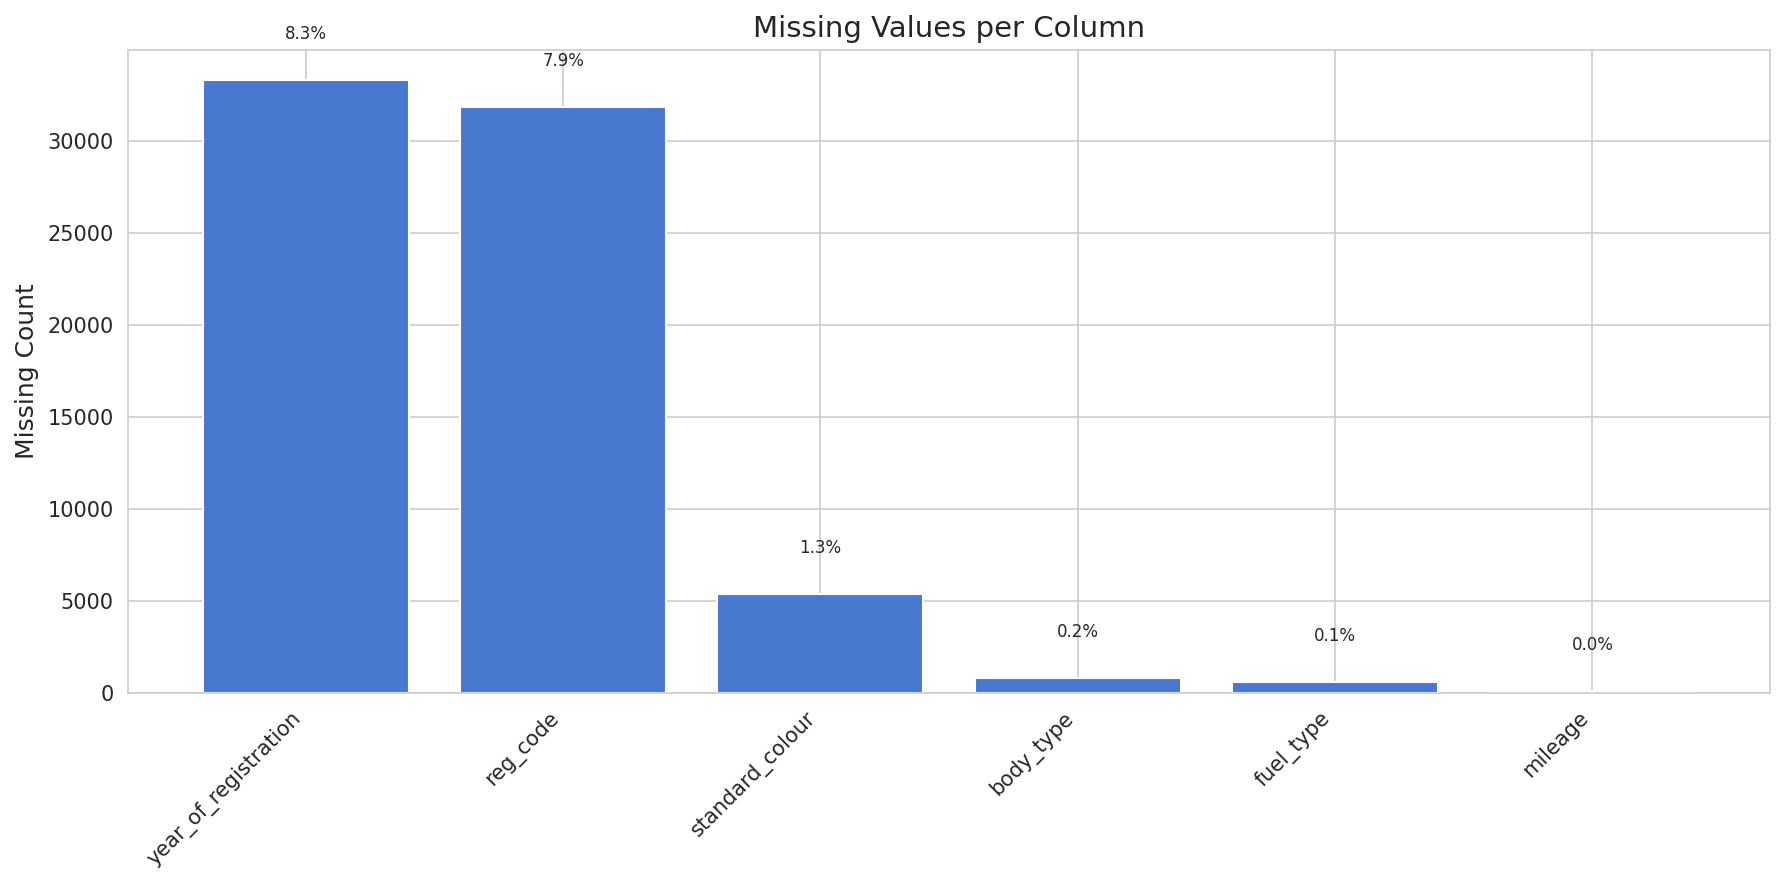


Total rows: 402,005
Columns with missing values: 6 / 12
                      missing_count   pct
year_of_registration          33311  8.29
reg_code                      31857  7.92
standard_colour                5378  1.34
body_type                       837  0.21
fuel_type                       601  0.15
mileage                         127  0.03


In [5]:
# ------------------------------------------------------------
# 1.1  Missing values per column (sorted bar chart)
# ------------------------------------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(missing)), missing.values, color=sns.color_palette("muted")[0])
ax.set_xticks(range(len(missing)))
ax.set_xticklabels(missing.index, rotation=45, ha="right")
ax.set_ylabel("Missing Count")
ax.set_title("Missing Values per Column")

# Annotate each bar with the percentage missing
for i, (count, col) in enumerate(zip(missing.values, missing.index)):
    pct = count / len(df) * 100
    ax.text(i, count + len(df) * 0.005, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
# fig.savefig("figures/missing_values.png")
plt.show()

print(f"\nTotal rows: {len(df):,}")
print(f"Columns with missing values: {len(missing)} / {df.shape[1]}")
print(missing.to_frame("missing_count").assign(
    pct=lambda x: (x["missing_count"] / len(df) * 100).round(2)
))

### 1.2 Target Variable Distribution

Car prices typically follow a right-skewed distribution — most adverts cluster at lower prices with a long tail of luxury and specialist vehicles. A log-scale view helps reveal the underlying structure more clearly and will inform whether a log-transform of the target is beneficial for modelling.

Using target column: 'price'


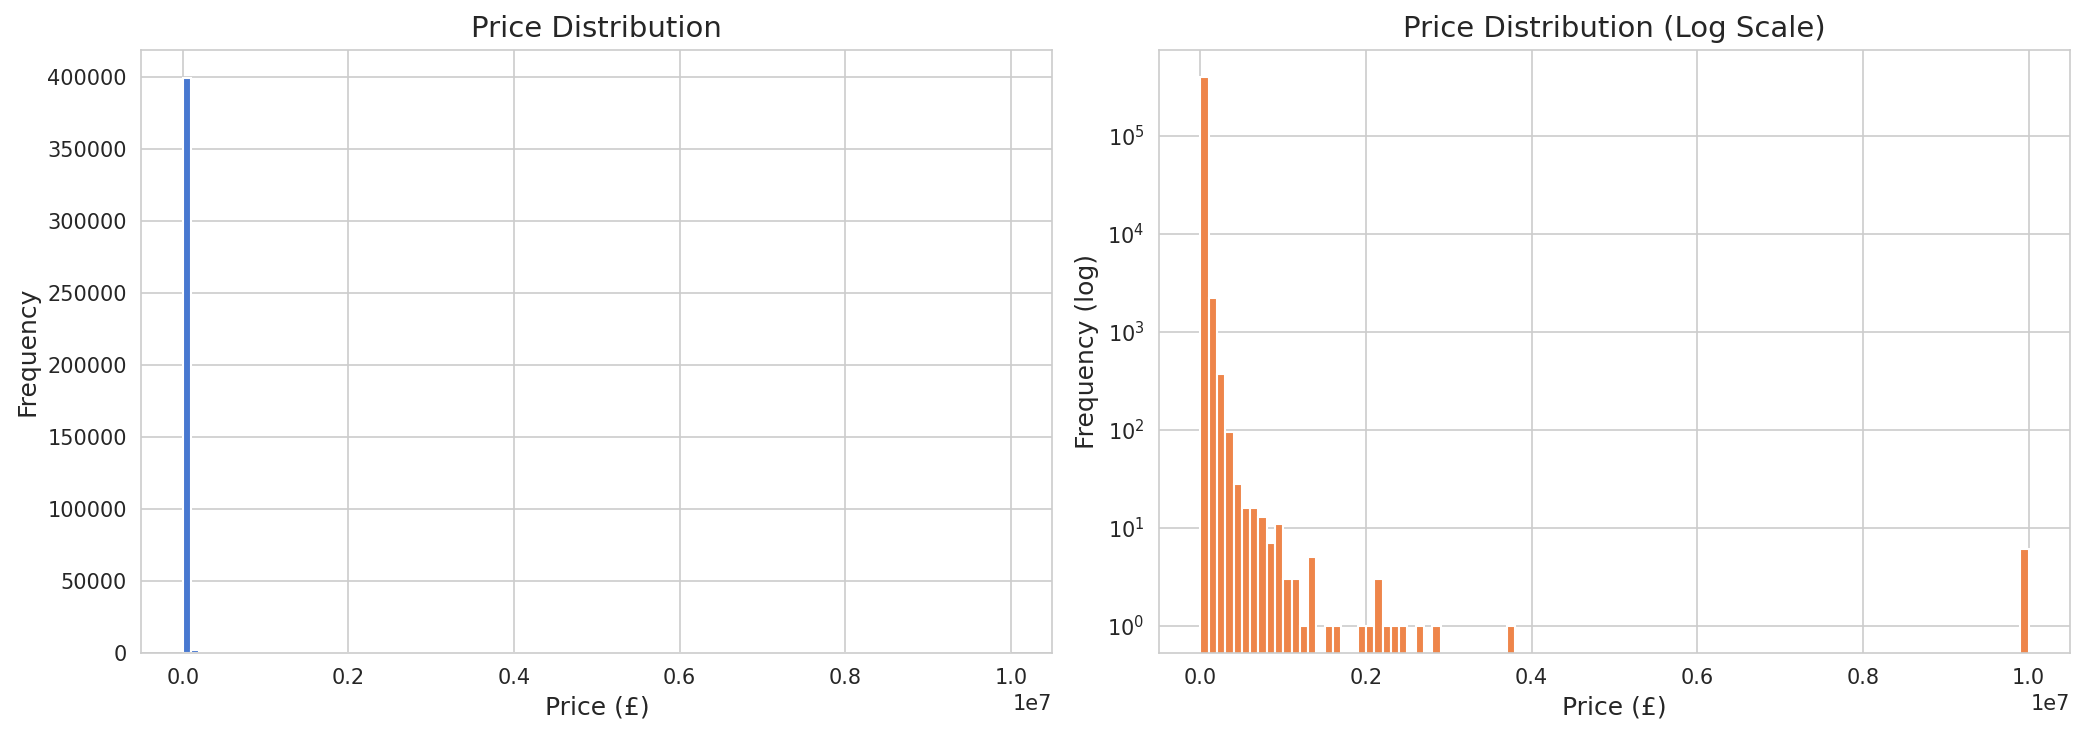


price summary statistics:
count    4.020050e+05
mean     1.734197e+04
std      4.643746e+04
min      1.200000e+02
25%      7.495000e+03
50%      1.260000e+04
75%      2.000000e+04
max      9.999999e+06

Skewness : 154.68
Kurtosis : 32182.67


In [6]:
# ------------------------------------------------------------
# 1.2  Price distribution — original & log scale
# ------------------------------------------------------------

# Identify the price column (common names in AutoTrader datasets)
price_col = None
for candidate in ["price", "Price", "selling_price", "price_in_pounds"]:
    if candidate in df.columns:
        price_col = candidate
        break

if price_col is None:
    # Fallback: pick the first column whose name contains "price"
    price_cols = [c for c in df.columns if "price" in c.lower()]
    if price_cols:
        price_col = price_cols[0]
    else:
        raise ValueError("Could not auto-detect a price column. Please set price_col manually.")

print(f"Using target column: '{price_col}'")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — raw scale
axes[0].hist(df[price_col].dropna(), bins=100, color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Frequency")

# Right — log scale
axes[1].hist(df[price_col].dropna(), bins=100, color=sns.color_palette("muted")[1], edgecolor="white", log=True)
axes[1].set_title("Price Distribution (Log Scale)")
axes[1].set_xlabel("Price (£)")
axes[1].set_ylabel("Frequency (log)")

plt.tight_layout()
# fig.savefig("figures/price_distribution.png")
plt.show()

# Summary stats for the target
print(f"\n{price_col} summary statistics:")
print(df[price_col].describe().to_string())
print(f"\nSkewness : {df[price_col].skew():.2f}")
print(f"Kurtosis : {df[price_col].kurtosis():.2f}")

### 1.3 Correlation Heatmap

The correlation matrix reveals linear relationships between numeric features. Strongly correlated feature pairs (|r| > 0.8) may introduce multicollinearity, while features with high absolute correlation to price are the most promising predictors.

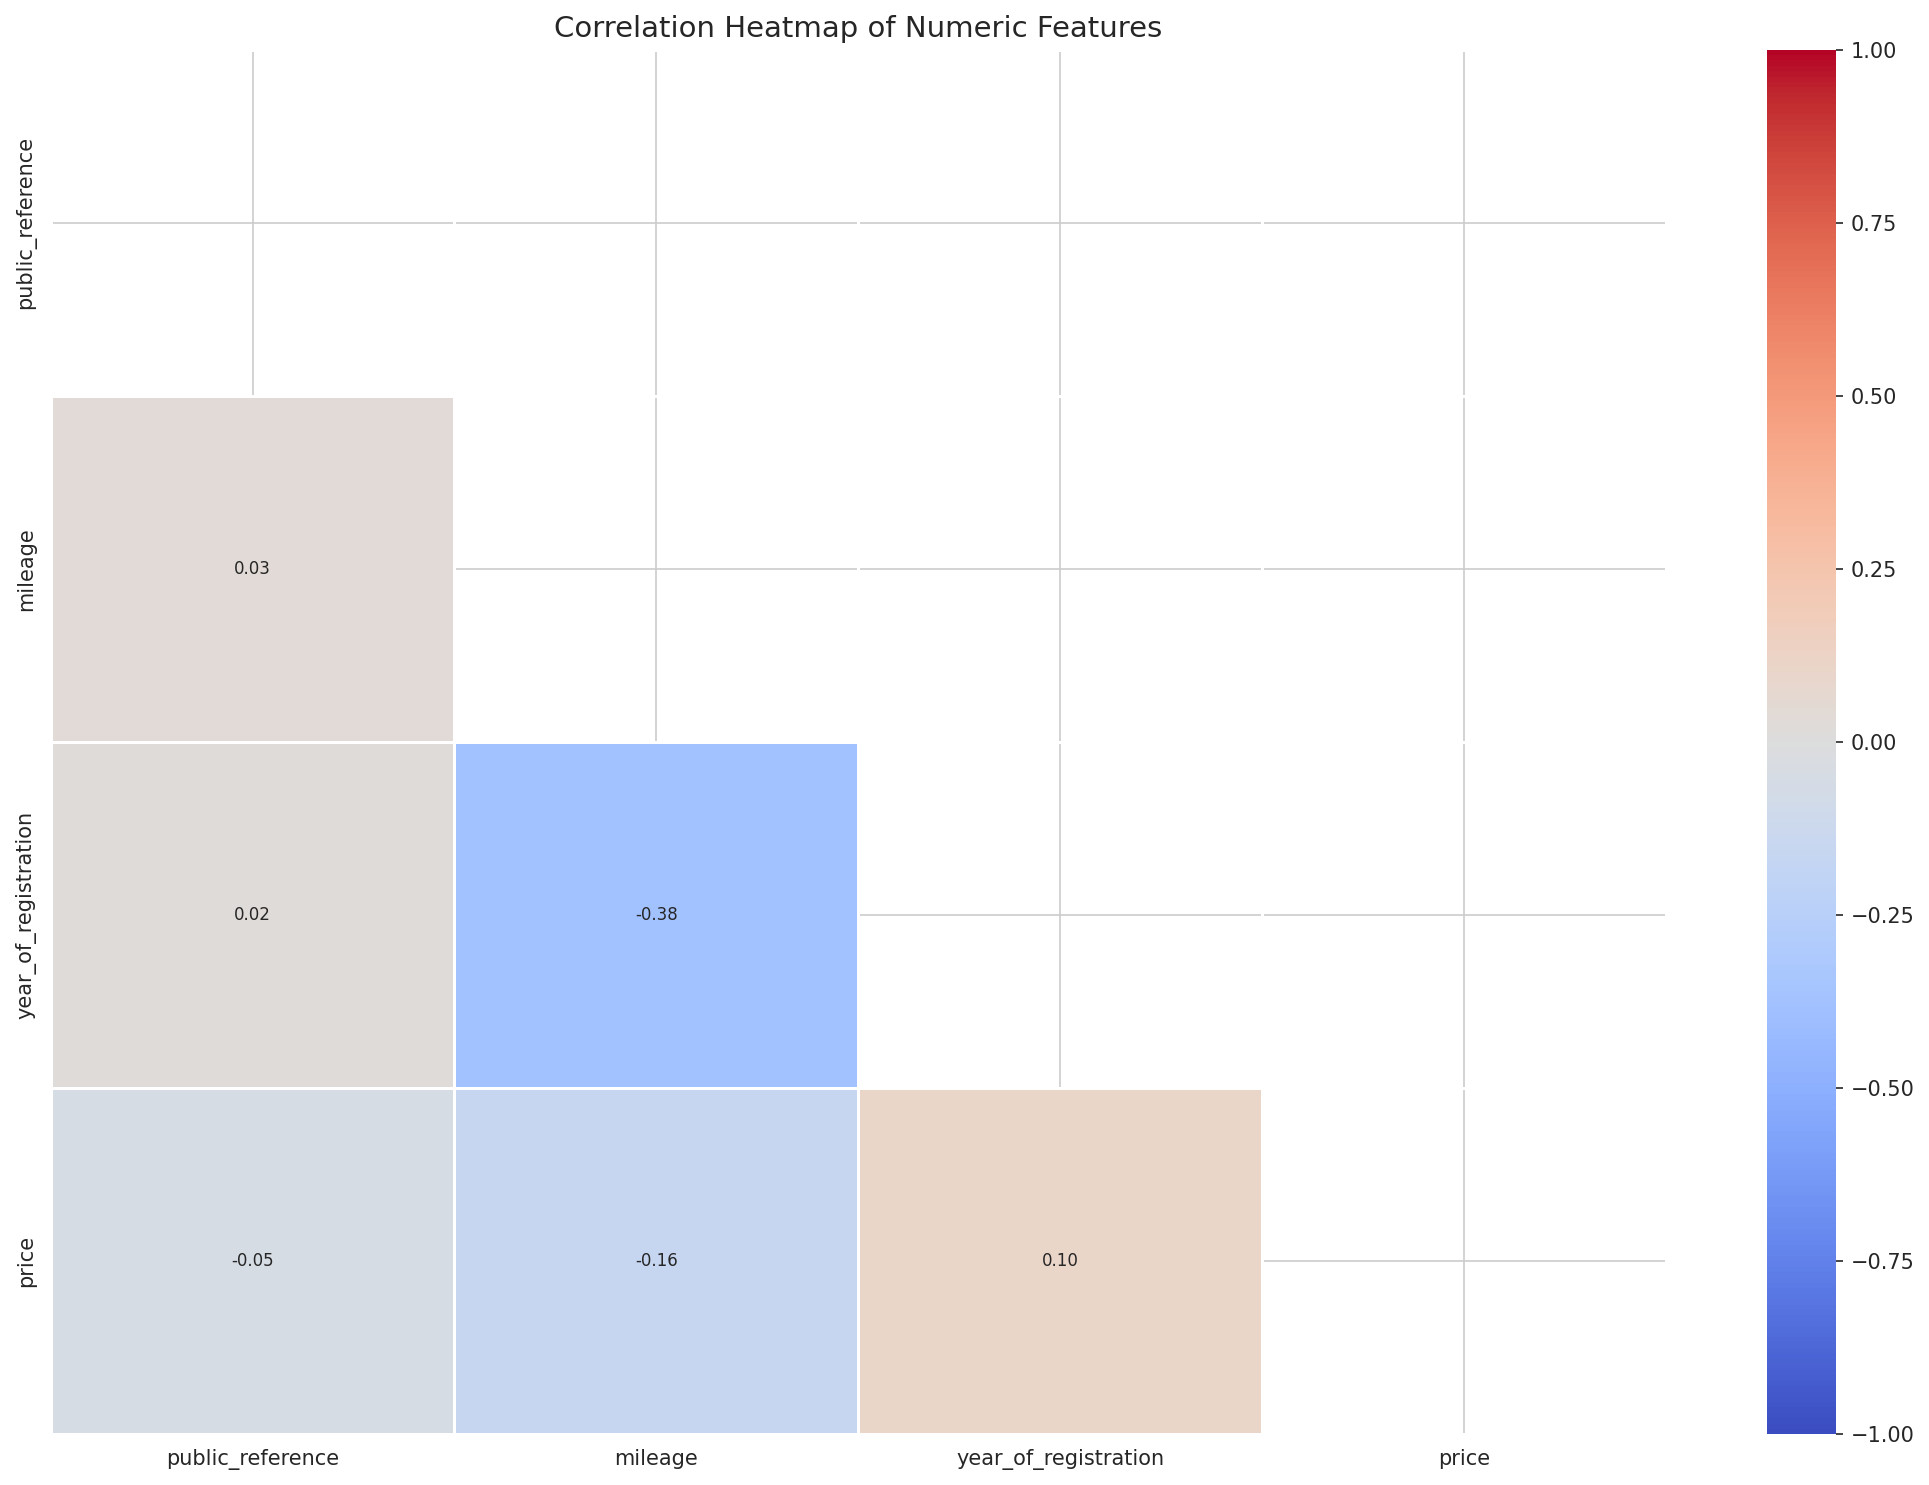

Top correlations with 'price':

mileage                 0.160204
year_of_registration    0.102341
public_reference        0.052344


In [7]:
# ------------------------------------------------------------
# 1.3  Correlation heatmap of numeric features
# ------------------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Mask the upper triangle for cleaner visual
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
# fig.savefig("figures/correlation_heatmap.png")
plt.show()

# Print the features most correlated with price
if price_col in corr.columns:
    price_corr = corr[price_col].drop(price_col).abs().sort_values(ascending=False)
    print(f"Top correlations with '{price_col}':\n")
    print(price_corr.to_string())

### 1.4 Categorical Feature Cardinality

High-cardinality categorical features (e.g. specific model names) can cause dimensionality explosion with one-hot encoding. Identifying these early helps us decide between target encoding, frequency encoding, or grouping rare categories.

In [8]:
# ------------------------------------------------------------
# 1.4  Unique value counts for categorical columns
# ------------------------------------------------------------
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}):\n")
print(f"{'Column':<30} {'Unique Values':>15} {'Cardinality':<15}")
print("-" * 62)

cardinality = {}
for col in cat_cols:
    n_unique = df[col].nunique()
    cardinality[col] = n_unique
    label = "HIGH" if n_unique > 50 else ("MEDIUM" if n_unique > 10 else "LOW")
    print(f"{col:<30} {n_unique:>15,}  {label}")

# Flag high-cardinality features
high_card = {k: v for k, v in cardinality.items() if v > 50}
if high_card:
    print(f"\nHigh-cardinality features (>50 unique values): {list(high_card.keys())}")
    print("Consider target encoding or frequency encoding for these columns.")

# Show top 10 most frequent values for each categorical column
print(f"\n{'='*60}")
print("Top 10 values per categorical column:")
print(f"{'='*60}")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10).to_string())

Categorical columns (7):

Column                           Unique Values Cardinality    
--------------------------------------------------------------
reg_code                                    72  HIGH
standard_colour                             22  MEDIUM
standard_make                              110  HIGH
standard_model                           1,168  HIGH
vehicle_condition                            2  LOW
body_type                                   16  MEDIUM
fuel_type                                    9  LOW

High-cardinality features (>50 unique values): ['reg_code', 'standard_make', 'standard_model']
Consider target encoding or frequency encoding for these columns.

Top 10 values per categorical column:

reg_code:
reg_code
17    36738
67    32230
66    25227
69    23825
18    21613
16    19998
19    18407
65    15635
68    15621
15    14010

standard_colour:
standard_colour
Black     86287
White     70535
Grey      68227
Blue      59784
Silver    49323
Red       42024
Gree

### 1.5 Preprocessing Cleanup & Feature Engineering

This step handles tasks that *cannot* be deferred to automated feature selection: dropping columns with >60% missing data (selection methods cannot score mostly-NaN columns), removing identifier columns that would cause overfitting (a unique ID per row would appear to predict perfectly on training data), and engineering `age` from `year_of_registration`. The near-zero-variance `crossover_car_and_van` column is deliberately kept here — Section 2's `VarianceThreshold` will catch and remove it automatically, demonstrating the method's value.

In [9]:
# ------------------------------------------------------------
# 1.5  Preprocessing cleanup & feature engineering
# ------------------------------------------------------------
print(f"Shape BEFORE cleaning: {df.shape}")
print(f"{'='*60}")

# --- a) Drop columns with >60% missing values ---
miss_pct = df.isnull().mean()
high_miss_cols = miss_pct[miss_pct > 0.60].index.tolist()
if high_miss_cols:
    print(f"Dropping columns with >60% missing: {high_miss_cols}")
    df.drop(columns=high_miss_cols, inplace=True)
else:
    print("No columns exceed 60% missingness.")

# --- b) Drop ID / index columns (would cause overfitting, not feature selection's job) ---
id_cols = [c for c in ["public_reference", "reg_code"] if c in df.columns]
if id_cols:
    print(f"Dropping ID columns: {id_cols}")
    df.drop(columns=id_cols, inplace=True)

# --- c) Feature-engineer 'age' from year_of_registration ---
if "year_of_registration" in df.columns:
    df["year_of_registration"] = df["year_of_registration"].fillna(2023)
    df["age"] = 2023 - df["year_of_registration"]
    df.drop(columns=["year_of_registration"], inplace=True)
    print("Engineered 'age' from year_of_registration (missing → 2023).")

# --- d) Keep crossover_car_and_van for VarianceThreshold to catch in Section 2 ---
if "crossover_car_and_van" in df.columns:
    df["crossover_car_and_van"] = df["crossover_car_and_van"].astype(int)
    pos_pct = df["crossover_car_and_van"].mean() * 100
    print(f"Keeping 'crossover_car_and_van' ({pos_pct:.2f}% positive) "
          f"— VarianceThreshold in Section 2 will handle this.")

print(f"\nShape AFTER cleanup: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape BEFORE cleaning: (402005, 12)
No columns exceed 60% missingness.
Dropping ID columns: ['public_reference', 'reg_code']
Engineered 'age' from year_of_registration (missing → 2023).
Keeping 'crossover_car_and_van' (0.45% positive) — VarianceThreshold in Section 2 will handle this.

Shape AFTER cleanup: (402005, 10)
Remaining columns: ['mileage', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'price', 'body_type', 'crossover_car_and_van', 'fuel_type', 'age']


### 1.6 Impute Remaining Missing Values

Numeric columns are imputed with the median (robust to the skewed distributions we observed), while categorical columns are filled with their mode where one clear dominant value exists, or `"Unknown"` otherwise.

In [10]:
# ------------------------------------------------------------
# 1.6  Impute remaining missing values
# ------------------------------------------------------------
print(f"Missing values BEFORE imputation:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")

# Numeric columns → median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if price_col in num_cols:
    num_cols.remove(price_col)  # don't impute the target

for col in num_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col}: filled {df[col].isnull().sum()} NaNs with median = {median_val:.1f}")

# Categorical columns → mode (if dominant) or "Unknown"
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            fill_val = mode_val[0]
        else:
            fill_val = "Unknown"
        n_missing = df[col].isnull().sum()
        df[col].fillna(fill_val, inplace=True)
        print(f"  {col}: filled {n_missing} NaNs with '{fill_val}'")

# Drop any rows still missing the target
before = len(df)
df.dropna(subset=[price_col], inplace=True)
dropped_target = before - len(df)
if dropped_target > 0:
    print(f"\nDropped {dropped_target} rows with missing target ({price_col}).")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Missing values BEFORE imputation:
mileage             127
standard_colour    5378
body_type           837
fuel_type           601
dtype: int64

  mileage: filled 0 NaNs with median = 28629.5
  standard_colour: filled 5378 NaNs with 'Black'
  body_type: filled 837 NaNs with 'Hatchback'
  fuel_type: filled 601 NaNs with 'Petrol'

Remaining missing values: 0
Shape: (402005, 10)


### 1.7 Outlier Handling

We apply domain-informed bounds: prices below £500 are likely listing errors, while prices above £150,000 represent a tiny fraction of ultra-luxury vehicles that would distort the model. Mileage is capped at 200,000 (beyond which listings are often commercial vehicles or data errors) and age at 30 years to exclude vintage/classic cars that follow different pricing dynamics.

In [11]:
# ------------------------------------------------------------
# 1.7  Outlier removal — domain-informed bounds
# ------------------------------------------------------------
n_before = len(df)

# Price bounds
PRICE_MIN = 500
PRICE_MAX = 150_000
df = df[(df[price_col] >= PRICE_MIN) & (df[price_col] <= PRICE_MAX)].copy()
print(f"Price filter (£{PRICE_MIN:,}–£{PRICE_MAX:,}): "
      f"removed {n_before - len(df):,} rows ({(n_before - len(df))/n_before*100:.2f}%)")

# Mileage cap
MILEAGE_CAP = 200_000
if "mileage" in df.columns:
    n_tmp = len(df)
    df = df[df["mileage"] <= MILEAGE_CAP].copy()
    print(f"Mileage cap (≤{MILEAGE_CAP:,}): removed {n_tmp - len(df):,} rows")

# Age cap
AGE_CAP = 30
if "age" in df.columns:
    n_tmp = len(df)
    df = df[df["age"] <= AGE_CAP].copy()
    print(f"Age cap (≤{AGE_CAP} years): removed {n_tmp - len(df):,} rows")

print(f"\nShape AFTER outlier removal: {df.shape}  "
      f"(total removed: {n_before - len(df):,} = {(n_before - len(df))/n_before*100:.1f}%)")

Price filter (£500–£150,000): removed 1,572 rows (0.39%)
Mileage cap (≤200,000): removed 333 rows
Age cap (≤30 years): removed 852 rows

Shape AFTER outlier removal: (399248, 10)  (total removed: 2,757 = 0.7%)


### 1.8 Feature Engineering: Brand Prestige

Reusing the domain-knowledge-driven prestige classification from last semester. This groups ~70+ car makes into 5 tiers based on typical market positioning, providing a powerful ordinal feature that captures the strong relationship between brand and price.

In [12]:
# ------------------------------------------------------------
# 1.8  Brand prestige classification (from last semester)
# ------------------------------------------------------------

# Define prestige levels with numbers as keys and lists of brands as values
PRESTIGE_LEVEL_BRANDS = {
    5: ['Ferrari', 'Lamborghini', 'McLaren', 'Bugatti', 'Pagani'],
    4: ['Bentley', 'Rolls-Royce', 'Maybach', 'Daimler', 'BAC'],
    3: ['Jaguar', 'Land Rover', 'Porsche', 'Maserati', 'Aston Martin', 'Lotus', 'TVR',
        'Morgan', 'Caterham', 'Noble', 'Ariel', 'Alpine', 'Corvette', 'Hummer', 'Radical',
        'Ultima', 'AC', 'Bristol', 'Jensen', 'Triumph'],
    2: ['Audi', 'BMW', 'Mercedes-Benz', 'Volkswagen', 'MINI', 'Volvo', 'Lexus',
        'Alfa Romeo', 'Subaru', 'Infiniti', 'Tesla', 'Abarth', 'Cadillac', 'Lincoln',
        'Saab', 'Lancia', 'Chrysler', 'Buick', 'Westfield', 'Zenos'],
    1: [ # Budget + Mass Market brands
        'Dacia', 'Perodua', 'Proton', 'SsangYong', 'Daewoo', 'Great Wall', 'Rover',
        'MG', 'Suzuki', 'Daihatsu', 'Datsun', 'Aixam', 'Reliant',
        'Vauxhall', 'SKODA', 'SEAT', 'Peugeot', 'Citroen', 'Renault', 'Fiat', 'Kia',
        'Hyundai', 'Nissan', 'Toyota', 'Honda', 'Mazda', 'Mitsubishi', 'Ford',
        'Chevrolet', 'Opel', 'Smart', 'DS AUTOMOBILES', 'CUPRA', 'Jeep', 'Dodge',
        'GMC', 'Isuzu', 'Pontiac', 'Plymouth', 'Holden', 'International',
        'London Taxis International', 'LEVC', 'Carbodies', 'Iveco',
        'Panther', 'Replica', 'Custom Vehicle', 'Dax', 'Tiger', 'Pilgrim', 'Mev',
        'Beauford', 'Sebring', 'Gentry', 'AK', 'Mitsuoka', 'Austin', 'Morris',
        'Leyland', 'Wolseley'
    ]
}

# Flatten the PRESTIGE_LEVEL_BRANDS into a brand-to-prestige-level map
# This is done for efficient lookup in the get_brand_prestige_class function
prestige_map = {}
for level, brands in PRESTIGE_LEVEL_BRANDS.items():
    for brand in brands:
        prestige_map[brand] = level

def get_brand_prestige_class(brand):
    return prestige_map.get(brand, 1)  # default to economy if unknown


if "standard_make" in df.columns:
    df["brand_prestige"] = df["standard_make"].apply(get_brand_prestige_class)
    print("Brand prestige distribution:")
    print(df.groupby("brand_prestige")[price_col].agg(["count", "mean", "median"]).round(0))
    print(f"\nNew column 'brand_prestige' added (1=Budget → 5=Exotic).")

Brand prestige distribution:
                 count      mean   median
brand_prestige                           
1               200915   10960.0   9500.0
2               168971   18914.0  15990.0
3                27586   35965.0  29995.0
4                 1046   67842.0  59997.0
5                  730  104755.0  99995.0

New column 'brand_prestige' added (1=Budget → 5=Exotic).


### 1.9 Reduce High-Cardinality Categoricals

For columns like `standard_make`, `standard_model`, `standard_colour`, and `body_type`, we keep only the most frequent values and bucket everything else as `"Other"`. This prevents rare categories (with very few samples) from creating noisy, unreliable encoded features. We deliberately keep `standard_model` here rather than dropping it — Section 2 will use automated feature selection to determine whether it carries useful signal.

In [13]:
# ------------------------------------------------------------
# 1.9  Bucket rare categories → "Other"
# ------------------------------------------------------------
def bucket_rare(df, column, top_n):
    """Keep top_n most frequent values, bucket the rest as 'Other'."""
    if column not in df.columns:
        return
    top = df[column].value_counts().nlargest(top_n).index
    before_unique = df[column].nunique()
    df[column] = df[column].where(df[column].isin(top), other="Other")
    print(f"  {column}: {before_unique} → {df[column].nunique()} categories (top {top_n} + Other)")

bucket_rare(df, "standard_make",   top_n=20)
bucket_rare(df, "standard_colour", top_n=10)
bucket_rare(df, "body_type",       top_n=8)
bucket_rare(df, "fuel_type",       top_n=4)
bucket_rare(df, "standard_model",  top_n=20)

# Verify
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\nCategorical columns after bucketing: {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

  standard_make: 98 → 21 categories (top 20 + Other)
  standard_colour: 22 → 11 categories (top 10 + Other)
  body_type: 16 → 9 categories (top 8 + Other)
  fuel_type: 9 → 5 categories (top 4 + Other)
  standard_model: 1032 → 21 categories (top 20 + Other)

Categorical columns after bucketing: ['standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type']
  standard_colour: 11 unique values
  standard_make: 21 unique values
  standard_model: 21 unique values
  vehicle_condition: 2 unique values
  body_type: 9 unique values
  fuel_type: 5 unique values


### 1.10 Encode Categorical Features

We use a mixed encoding strategy:
- **Ordinal encoding** for `fuel_type` and `vehicle_condition` which have a natural ordering (e.g. petrol < hybrid < electric; used < nearly-new < new).
- **Frequency encoding** for high-cardinality columns like `standard_make` — this preserves information about how common a category is without creating hundreds of dummy columns. We also apply it to `standard_colour`, `body_type`, and `standard_model` if present.

In [14]:
# ------------------------------------------------------------
# 1.10  Encode categorical features
# ------------------------------------------------------------

# --- a) Ordinal encoding for features with natural ordering ---
fuel_order = {
    "Petrol": 0, "Diesel": 1, "Petrol Hybrid": 2,
    "Petrol Plug-in Hybrid": 3, "Electric": 4, "Other": 5
}

condition_order = {"USED": 0, "NEARLY NEW": 1, "NEW": 2, "Unknown": 0, "Other": 0}

if "fuel_type" in df.columns:
    df["fuel_type_enc"] = df["fuel_type"].map(fuel_order).fillna(5).astype(int)
    print(f"fuel_type → ordinal encoded (0–5)")
    df.drop(columns=["fuel_type"], inplace=True)

if "vehicle_condition" in df.columns:
    df["vehicle_condition_enc"] = (
        df["vehicle_condition"].str.upper().map(condition_order).fillna(0).astype(int)
    )
    print(f"vehicle_condition → ordinal encoded (0–2)")
    df.drop(columns=["vehicle_condition"], inplace=True)

# --- b) Frequency encoding for remaining categoricals ---
freq_encode_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns]
print(f"\nFrequency-encoding: {freq_encode_cols}")

freq_maps = {}
for col in freq_encode_cols:
    freq = df[col].value_counts(normalize=True)
    freq_maps[col] = freq.to_dict()
    df[f"{col}_freq"] = df[col].map(freq).astype(float)
    df.drop(columns=[col], inplace=True)
    print(f"  {col} → {col}_freq  (range: {df[f'{col}_freq'].min():.4f} – {df[f'{col}_freq'].max():.4f})")

print(f"\nAll categoricals encoded. Remaining dtypes:")
print(df.dtypes.value_counts())

fuel_type → ordinal encoded (0–5)
vehicle_condition → ordinal encoded (0–2)

Frequency-encoding: ['standard_colour', 'standard_make', 'standard_model', 'body_type']
  standard_colour → standard_colour_freq  (range: 0.0050 – 0.2279)
  standard_make → standard_make_freq  (range: 0.0187 – 0.1045)
  standard_model → standard_model_freq  (range: 0.0092 – 0.6726)
  body_type → body_type_freq  (range: 0.0015 – 0.4201)

All categoricals encoded. Remaining dtypes:
float64    6
int64      5
Name: count, dtype: int64


### 1.11 Feature Scaling & Train / Validation / Test Split

We split into **70% train / 15% validation / 15% test** using stratified sampling on binned price to ensure each split has a similar price distribution. The `StandardScaler` is fitted on training data only, then applied to validation and test sets to prevent data leakage. A 50K-row prototyping sample is also created for faster iteration during model development.

In [15]:
# ------------------------------------------------------------
# 1.11  Train (70%) / Validation (15%) / Test (15%) split
#        + StandardScaler (fit on train only)
# ------------------------------------------------------------

# Log-transform the target (reduces right-skew)
y = np.log1p(df[price_col])
X = df.drop(columns=[price_col])

# Bin the target into quantile-based strata for stratified splitting
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X, y, y_bins, test_size=0.30, random_state=SEED, stratify=y_bins
)

# Second split: split the 30% temp into 15% val + 15% test (50/50)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=bins_temp
)

print(f"Train set      : {X_train.shape}")
print(f"Validation set : {X_val.shape}")
print(f"Test set       : {X_test.shape}")
print(f"Total          : {len(X_train) + len(X_val) + len(X_test):,}")

# --- Fit scaler on training data only, transform all three sets ---
scaler = StandardScaler()
feature_names = X_train.columns.tolist()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=feature_names, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names, index=X_test.index
)

print(f"\nScaler fitted on {len(feature_names)} features (saved as 'scaler').")
print(f"Train features — mean ≈ 0: {X_train_scaled.mean().abs().max():.6f}, "
      f"std ≈ 1: {X_train_scaled.std().mean():.4f}")

# --- Prototyping sample (50K rows from training set) ---
SAMPLE_SIZE = 50_000
if len(X_train_scaled) > SAMPLE_SIZE:
    sample_idx = X_train_scaled.sample(n=SAMPLE_SIZE, random_state=SEED).index
    X_train_sample = X_train_scaled.loc[sample_idx]
    y_train_sample = y_train.loc[sample_idx]
else:
    X_train_sample = X_train_scaled.copy()
    y_train_sample = y_train.copy()

print(f"\nPrototyping sample: {X_train_sample.shape}  (for fast iteration)")

Train set      : (279473, 10)
Validation set : (59887, 10)
Test set       : (59888, 10)
Total          : 399,248

Scaler fitted on 10 features (saved as 'scaler').
Train features — mean ≈ 0: 0.000000, std ≈ 1: 1.0000

Prototyping sample: (50000, 10)  (for fast iteration)


### 1.12 Final Dataset Summary

This table is the reference for all remaining sections. Every feature listed below, along with `X_train_scaled`, `X_val_scaled`, `X_test_scaled` and the corresponding `y_` targets, feeds directly into Sections 2–10.

In [16]:
# ------------------------------------------------------------
# 1.12  Summary table of final feature set
# ------------------------------------------------------------

# Build encoding-method lookup
encoding_method = {}
for col in feature_names:
    if col in ("fuel_type_enc",):
        encoding_method[col] = "Ordinal (fuel hierarchy)"
    elif col in ("vehicle_condition_enc",):
        encoding_method[col] = "Ordinal (condition)"
    elif col.endswith("_freq"):
        encoding_method[col] = "Frequency encoding"
    elif col == "brand_prestige":
        encoding_method[col] = "Domain mapping (1–5)"
    else:
        encoding_method[col] = "Raw numeric"

summary_rows = []
for col in feature_names:
    raw = X_train[col]
    summary_rows.append({
        "Feature": col,
        "Type": str(raw.dtype),
        "Min": f"{raw.min():.2f}",
        "Median": f"{raw.median():.2f}",
        "Max": f"{raw.max():.2f}",
        "Encoding": encoding_method.get(col, "—"),
    })

summary_df = pd.DataFrame(summary_rows)

print(f"{'='*70}")
print(f"  FINAL DATASET SUMMARY")
print(f"{'='*70}")
print(f"  Features        : {len(feature_names)}")
print(f"  Target           : log1p({price_col})")
print(f"  Train set        : {X_train_scaled.shape[0]:>8,} rows  × {X_train_scaled.shape[1]} features")
print(f"  Validation set   : {X_val_scaled.shape[0]:>8,} rows  × {X_val_scaled.shape[1]} features")
print(f"  Test set         : {X_test_scaled.shape[0]:>8,} rows  × {X_test_scaled.shape[1]} features")
print(f"  Prototype sample : {X_train_sample.shape[0]:>8,} rows  (for fast iteration)")
print(f"{'='*70}")
print()
print("Available variables for Sections 2–10:")
print("  X_train_scaled, X_val_scaled, X_test_scaled")
print("  y_train, y_val, y_test")
print("  X_train_sample, y_train_sample  (50K subset)")
print("  scaler, feature_names, freq_maps")
print()
summary_df

  FINAL DATASET SUMMARY
  Features        : 10
  Target           : log1p(price)
  Train set        :  279,473 rows  × 10 features
  Validation set   :   59,887 rows  × 10 features
  Test set         :   59,888 rows  × 10 features
  Prototype sample :   50,000 rows  (for fast iteration)

Available variables for Sections 2–10:
  X_train_scaled, X_val_scaled, X_test_scaled
  y_train, y_val, y_test
  X_train_sample, y_train_sample  (50K subset)
  scaler, feature_names, freq_maps



,Feature,Type,Min,Median,Max,Encoding
0,mileage,float64,0.00,28657.00,200000.00,Raw numeric
1,crossover_car_and_van,int64,0.00,0.00,1.00,Raw numeric
2,age,float64,0.00,6.00,30.00,Raw numeric
3,brand_prestige,int64,1.00,1.00,5.00,Domain mapping (1–5)
4,fuel_type_enc,int64,0.00,0.00,5.00,Ordinal (fuel hierarchy)
5,vehicle_condition_enc,int64,0.00,0.00,2.00,Ordinal (condition)
6,standard_colour_freq,float64,0.01,0.17,0.23,Frequency encoding
7,standard_make_freq,float64,0.02,0.08,0.10,Frequency encoding
8,standard_model_freq,float64,0.01,0.67,0.67,Frequency encoding
9,body_type_freq,float64,0.00,0.29,0.42,Frequency encoding


---
## 2. Automated Feature Selection

### 2.1 Unsupervised: VarianceThreshold

The simplest feature selection strategy — remove any feature whose variance falls below a threshold, without consulting the target variable. Since our features are standardised (std ≈ 1), most will have variance ≈ 1. A threshold of 0.01 catches near-constant features like `crossover_car_and_van` (which we deliberately kept in Section 1.5 for this purpose).

In [17]:
# ------------------------------------------------------------
# 2.1  VarianceThreshold (unsupervised)
# ------------------------------------------------------------
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_sample)

variances = pd.Series(vt.variances_, index=feature_names).sort_values(ascending=False)
kept_vt = [f for f, s in zip(feature_names, vt.get_support()) if s]
removed_vt = [f for f, s in zip(feature_names, vt.get_support()) if not s]

print("Feature variances (on scaled data):")
for feat, var in variances.items():
    marker = "✓" if feat in kept_vt else "✗ REMOVED"
    print(f"  {marker}  {feat:30s}  variance = {var:.4f}")

if removed_vt:
    print(f"\nRemoved by VarianceThreshold: {removed_vt}")
    # Update scaled datasets to drop low-variance features
    X_train_scaled.drop(columns=removed_vt, inplace=True)
    X_val_scaled.drop(columns=removed_vt, inplace=True)
    X_test_scaled.drop(columns=removed_vt, inplace=True)
    X_train_sample = X_train_sample.drop(columns=removed_vt)
    y_train_sample = y_train_sample  # unchanged
    feature_names = X_train_scaled.columns.tolist()
    print(f"Updated feature set: {len(feature_names)} features remaining.")
else:
    print(f"\nNo features removed — all variances exceed 0.01.")

Feature variances (on scaled data):
  ✓  age                             variance = 1.0167
  ✓  mileage                         variance = 1.0137
  ✓  fuel_type_enc                   variance = 1.0131
  ✓  brand_prestige                  variance = 1.0040
  ✓  standard_colour_freq            variance = 1.0040
  ✓  body_type_freq                  variance = 1.0027
  ✓  standard_make_freq              variance = 1.0004
  ✓  standard_model_freq             variance = 1.0000
  ✓  vehicle_condition_enc           variance = 0.9948
  ✓  crossover_car_and_van           variance = 0.9394

No features removed — all variances exceed 0.01.


### 2.2 Supervised Univariate: SelectKBest with Mutual Information

Mutual information measures non-linear statistical dependency between each feature and the target. Unlike Pearson correlation, it captures arbitrary relationships. We evaluate at several values of `k` to see how the selected set evolves.

Mutual Information scores (all features):
age                      0.526037
mileage                  0.348596
standard_make_freq       0.218966
brand_prestige           0.156009
body_type_freq           0.142706
standard_model_freq      0.114284
vehicle_condition_enc    0.113255
fuel_type_enc            0.060174
standard_colour_freq     0.043234
crossover_car_and_van    0.000000

k=  3: ['mileage', 'age', 'standard_make_freq']
k=  5: ['mileage', 'age', 'brand_prestige', 'standard_make_freq', 'body_type_freq']
k=  7: ['mileage', 'age', 'brand_prestige', 'vehicle_condition_enc', 'standard_make_freq', 'standard_model_freq', 'body_type_freq']
k=all: ['mileage', 'crossover_car_and_van', 'age', 'brand_prestige', 'fuel_type_enc', 'vehicle_condition_enc', 'standard_colour_freq', 'standard_make_freq', 'standard_model_freq', 'body_type_freq']


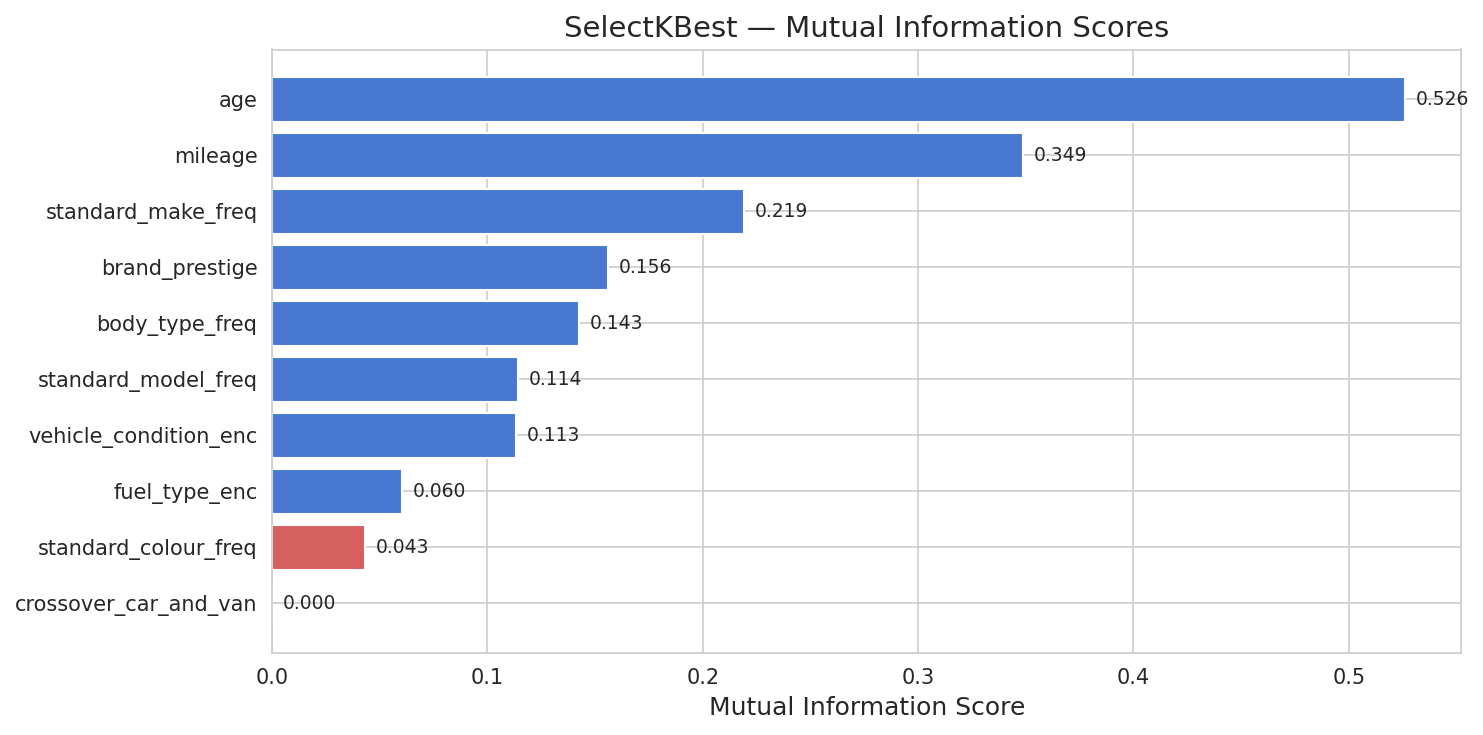


MI subset for comparison (k=5): ['mileage', 'age', 'brand_prestige', 'standard_make_freq', 'body_type_freq']


In [19]:
# ------------------------------------------------------------
# 2.2  SelectKBest with mutual_info_regression
# ------------------------------------------------------------
n_total = X_train_sample.shape[1]

# Compute MI scores once
mi_scores = mutual_info_regression(X_train_sample, y_train_sample, random_state=SEED)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

# Try several k values
k_values = [k for k in [3, 5, 7] if k <= n_total] + [n_total]

print("Mutual Information scores (all features):")
print(mi_series.to_string())
print()

skb_results = {}
for k in k_values:
    label = "all" if k == n_total else str(k)
    selector = SelectKBest(mutual_info_regression, k=k)
    selector.fit(X_train_sample, y_train_sample)
    selected = [f for f, s in zip(feature_names, selector.get_support()) if s]
    skb_results[k] = selected
    print(f"k={label:>3s}: {selected}")

# --- Bar chart of MI scores ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = [sns.color_palette("muted")[0] if v > 0.05 else sns.color_palette("muted")[3]
          for v in mi_series.values]
ax.barh(mi_series.index[::-1], mi_series.values[::-1], color=colors[::-1], edgecolor="white")
ax.set_xlabel("Mutual Information Score")
ax.set_title("SelectKBest — Mutual Information Scores")
for i, (feat, score) in enumerate(zip(mi_series.index[::-1], mi_series.values[::-1])):
    ax.text(score + 0.005, i, f"{score:.3f}", va="center", fontsize=9)
plt.tight_layout()
# fig.savefig("figures/selectkbest_scores.png")
plt.show()
# Use k=5 as the representative MI subset for comparison
best_k = min(5, n_total)
mi_selected = skb_results[best_k]
print(f"\nMI subset for comparison (k={best_k}): {mi_selected}")


### 2.3 Multivariate: RFECV (Recursive Feature Elimination with Cross-Validation)

RFE iteratively removes the least important feature and re-evaluates model performance. Wrapping it in cross-validation (RFECV) finds the optimal number of features automatically. We use a Random Forest estimator to capture non-linear interactions during elimination, with `cv=3` for speed.

Optimal number of features: 10
Selected features: ['mileage', 'crossover_car_and_van', 'age', 'brand_prestige', 'fuel_type_enc', 'vehicle_condition_enc', 'standard_colour_freq', 'standard_make_freq', 'standard_model_freq', 'body_type_freq']

Feature rankings:
  1. mileage
  1. crossover_car_and_van
  1. age
  1. brand_prestige
  1. fuel_type_enc
  1. vehicle_condition_enc
  1. standard_colour_freq
  1. standard_make_freq
  1. standard_model_freq
  1. body_type_freq


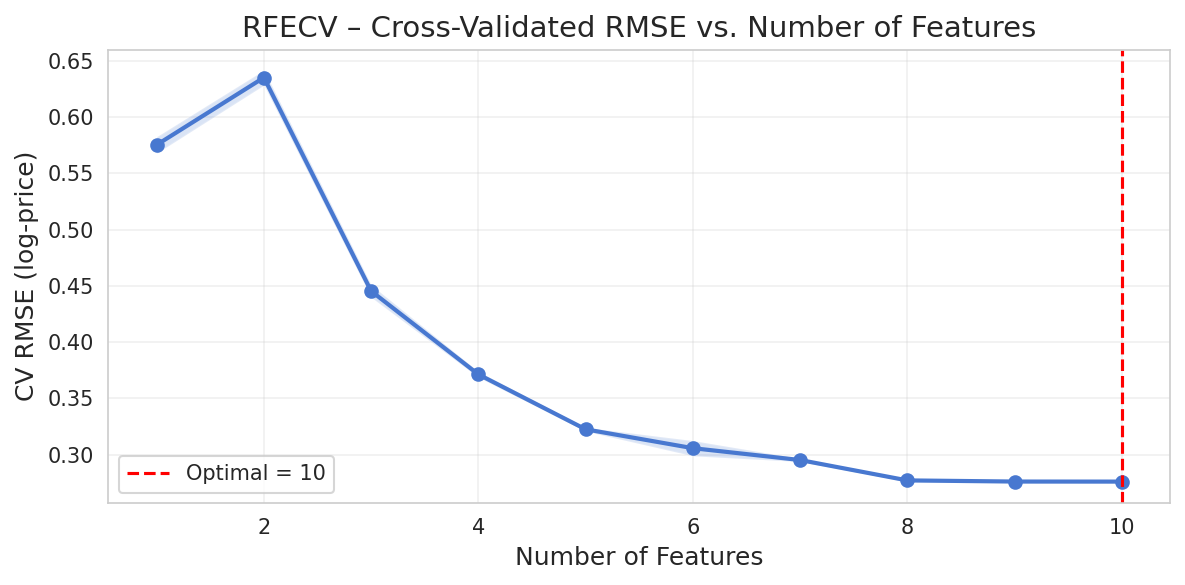

In [21]:
# ------------------------------------------------------------
# 2.3  RFECV (Recursive Feature Elimination with CV)
# ------------------------------------------------------------
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor

rf_rfecv = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rfecv = RFECV(
    estimator=rf_rfecv,
    step=1,
    cv=3,
    scoring="neg_root_mean_squared_error",
    min_features_to_select=1,
    n_jobs=-1
)

rfecv.fit(X_train_sample, y_train_sample)

rfecv_mask = rfecv.support_
rfecv_ranking = rfecv.ranking_
rfecv_selected = [f for f, s in zip(feature_names, rfecv_mask) if s]

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {rfecv_selected}")
print(f"\nFeature rankings:")
for f, r in sorted(zip(feature_names, rfecv_ranking), key=lambda x: x[1]):
    print(f"  {r}. {f}")

# --- RFECV curve ---
import matplotlib.pyplot as plt
import numpy as np

cv_results = rfecv.cv_results_
mean_scores = -cv_results["mean_test_score"]   # flip sign → RMSE
std_scores  =  cv_results["std_test_score"]
n_features_range = range(1, len(mean_scores) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_features_range, mean_scores, "o-", linewidth=2)
ax.fill_between(n_features_range,
                mean_scores - std_scores,
                mean_scores + std_scores, alpha=0.2)
ax.axvline(rfecv.n_features_, color="red", linestyle="--",
           label=f"Optimal = {rfecv.n_features_}")
ax.set_xlabel("Number of Features")
ax.set_ylabel("CV RMSE (log-price)")
ax.set_title("RFECV – Cross-Validated RMSE vs. Number of Features")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("figures/rfecv_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Multivariate: SelectFromModel (Random Forest Importances)

SelectFromModel selects features whose importance exceeds a given threshold. Using `threshold="median"` keeps roughly the **top half** of features — a more aggressive filter than RFECV, which tends to retain most features.

In [22]:
# ------------------------------------------------------------
# 2.4  SelectFromModel (RF importances, threshold = median)
# ------------------------------------------------------------
from sklearn.feature_selection import SelectFromModel

rf_sfm = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_sfm.fit(X_train_sample, y_train_sample)

sfm = SelectFromModel(rf_sfm, threshold="median", prefit=True)

sfm_mask = sfm.get_support()
sfm_selected = [f for f, s in zip(feature_names, sfm_mask) if s]

print(f"Features selected (threshold='median'): {len(sfm_selected)}")
print(f"Selected: {sfm_selected}\n")

importances = rf_sfm.feature_importances_
median_imp  = np.median(importances)
print(f"Median importance: {median_imp:.4f}\n")
print("Feature importances:")
for f, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    marker = "✓" if imp >= median_imp else " "
    print(f"  {marker} {f:30s}  {imp:.4f}")

Features selected (threshold='median'): 5
Selected: ['mileage', 'age', 'brand_prestige', 'standard_make_freq', 'body_type_freq']

Median importance: 0.0318

Feature importances:
  ✓ age                             0.5172
  ✓ brand_prestige                  0.1938
  ✓ mileage                         0.1205
  ✓ body_type_freq                  0.0720
  ✓ standard_make_freq              0.0446
    fuel_type_enc                   0.0189
    standard_colour_freq            0.0171
    standard_model_freq             0.0138
    crossover_car_and_van           0.0013
    vehicle_condition_enc           0.0007


### 2.5 Multivariate: Sequential Feature Selection (Forward)

SFS is a greedy wrapper method that adds one feature at a time, choosing whichever gives the best cross-validated score. We fix `n_features_to_select=5` to force a compact subset and use a lighter forest (50 trees) to manage compute cost.

In [23]:
# ------------------------------------------------------------
# 2.5  Sequential Feature Selection (forward, 5 features)
# ------------------------------------------------------------
from sklearn.feature_selection import SequentialFeatureSelector

rf_sfs = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

sfs = SequentialFeatureSelector(
    rf_sfs,
    n_features_to_select=5,
    direction="forward",
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

sfs.fit(X_train_sample, y_train_sample)

sfs_mask = sfs.get_support()
sfs_selected = [f for f, s in zip(feature_names, sfs_mask) if s]

print(f"SFS selected {len(sfs_selected)} features:")
for f in sfs_selected:
    print(f"  • {f}")

SFS selected 5 features:
  • age
  • brand_prestige
  • fuel_type_enc
  • standard_make_freq
  • body_type_freq


### 2.6 Feature Selection Comparison

A heatmap summarising which features were selected by each method. Features selected by the majority of methods form the **consensus set**.

Selection matrix:
                       MI (k=best)  RFECV  SFM (median)  SFS (5)  votes
mileage                          1      1             1        0      3
crossover_car_and_van            0      1             0        0      1
age                              1      1             1        1      4
brand_prestige                   1      1             1        1      4
fuel_type_enc                    0      1             0        1      2
vehicle_condition_enc            0      1             0        0      1
standard_colour_freq             0      1             0        0      1
standard_make_freq               1      1             1        1      4
standard_model_freq              0      1             0        0      1
body_type_freq                   1      1             1        1      4

Consensus features (≥3 votes): ['mileage', 'age', 'brand_prestige', 'standard_make_freq', 'body_type_freq']


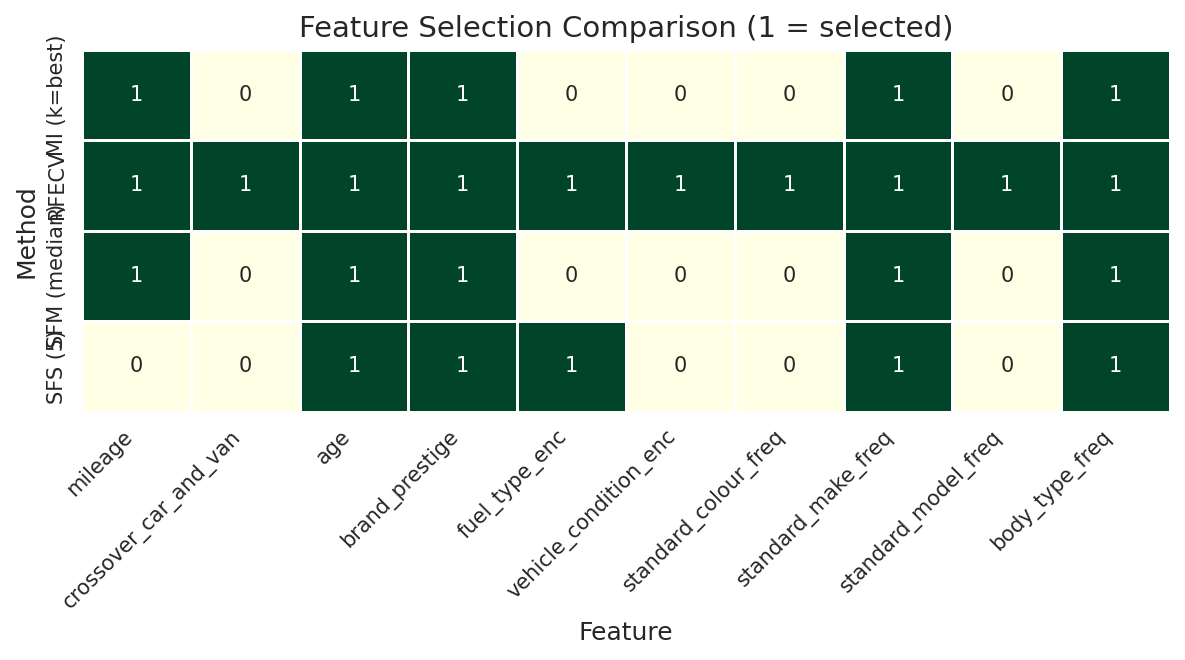

In [25]:
# ------------------------------------------------------------
# 2.6  Comparison heatmap
# ------------------------------------------------------------
import pandas as pd
import seaborn as sns

# Build selection matrix (post-VarianceThreshold feature set)
methods = {
    "MI (k=best)": [f in mi_selected for f in feature_names],
    "RFECV":       [f in rfecv_selected for f in feature_names],
    "SFM (median)": [f in sfm_selected for f in feature_names],
    "SFS (5)":     [f in sfs_selected for f in feature_names],
}

sel_df = pd.DataFrame(methods, index=feature_names).astype(int)
sel_df["votes"] = sel_df.sum(axis=1)

# Consensus = selected by majority (>= 3 of 4 supervised methods)
consensus_features = sel_df[sel_df["votes"] >= 3].index.tolist()

print("Selection matrix:")
print(sel_df.to_string())
print(f"\nConsensus features (≥3 votes): {consensus_features}")

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.45)))
sns.heatmap(
    sel_df.drop(columns="votes").T,
    annot=True, cmap="YlGn", cbar=False,
    linewidths=0.5, linecolor="white",
    yticklabels=True, xticklabels=True, ax=ax
)
ax.set_title("Feature Selection Comparison (1 = selected)")
ax.set_xlabel("Feature")
ax.set_ylabel("Method")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig("figures/feature_selection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.7 Evaluation with Ridge Regression

We compare how each feature subset performs with a simple Ridge regression on the **validation set** — measuring R², RMSE, and MAE in both log-space and real £.

In [26]:
# ------------------------------------------------------------
# 2.7  Ridge evaluation on multiple subsets
# ------------------------------------------------------------
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

subsets = {
    "All features":   feature_names,
    "MI (k=best)":    mi_selected,
    "RFECV":          rfecv_selected,
    "SFM (median)":   sfm_selected,
    "SFS (5)":        sfs_selected,
    "Consensus (≥3)": consensus_features,
}

results = []
for name, feats in subsets.items():
    if len(feats) == 0:
        continue
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled[feats], y_train)
    y_pred_log = ridge.predict(X_val_scaled[feats])

    # Log-space metrics
    r2   = r2_score(y_val, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae  = mean_absolute_error(y_val, y_pred_log)

    # Real £ metrics
    y_pred_real = np.expm1(y_pred_log)
    y_val_real  = np.expm1(y_val)
    rmse_gbp = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
    mae_gbp  = mean_absolute_error(y_val_real, y_pred_real)

    results.append({
        "Subset": name,
        "#Feats": len(feats),
        "R² (log)": round(r2, 4),
        "RMSE (log)": round(rmse, 4),
        "MAE (log)": round(mae, 4),
        "RMSE (£)": round(rmse_gbp, 0),
        "MAE (£)": round(mae_gbp, 0),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

        Subset  #Feats  R² (log)  RMSE (log)  MAE (log)  RMSE (£)  MAE (£)
  All features      10    0.8030      0.3693     0.2738    8426.0   4462.0
   MI (k=best)       5    0.7848      0.3859     0.2904    8807.0   4767.0
         RFECV      10    0.8030      0.3693     0.2738    8426.0   4462.0
  SFM (median)       5    0.7848      0.3859     0.2904    8807.0   4767.0
       SFS (5)       5    0.7559      0.4111     0.2985    9270.0   4841.0
Consensus (≥3)       5    0.7848      0.3859     0.2904    8807.0   4767.0


### 2.8 Analysis

*To be completed after running all cells — observations on which methods agree, which features are universally important, and which subset offers the best complexity-performance trade-off for the tree-ensemble models in Section 3.*

---
## 3. Tree Ensembles

---
## 4. Ensemble of Tree Ensembles

---
## 5. Feature Importance

---
## 6. SHAP/PDP Model Explanations

---
## 7. Dimensionality Reduction (Linear)

---
## 8. Dimensionality Reduction (Non-Linear)

---
## 9. Polynomial Regression

---
## 10. Clustering for Feature Engineering